In [18]:
# Import all needed libraries
import os
import numpy as np
import warnings
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
try:
    import sklearn
    from sklearn.decomposition import PCA
except ImportError:
    warnings.warn("sklearn is not installed. Please install it to use PCA functions. ")

In [19]:
def process_pca_compression(image_path, k):
    """
    Nén ảnh màu bằng cách áp dụng PCA lên từng kênh R, G, B
    """
    if not os.path.exists(image_path):
        return None, 0

    # Load ảnh
    img = Image.open(image_path)
    img_array = np.array(img)
    height, width, channels = img_array.shape
    
    # List chứa 3 kênh sau khi tái tạo
    reconstructed_channels = []
    total_variance_retained = 0
    
    # Xử lý từng kênh màu
    for i in range(channels):
        channel_data = img_array[:, :, i]
        
        # Dùng thư viện sklearn PCA
        # Lưu ý: PCA giảm chiều của features (cột), tức là chiều Width
        pca = PCA(n_components=k)
        
        # Fit và Nén (Transform)
        transformed = pca.fit_transform(channel_data)
        
        # Giải nén (Inverse Transform)
        reconstructed = pca.inverse_transform(transformed)
        
        reconstructed_channels.append(reconstructed)
        
        # Cộng dồn phương sai giữ lại
        total_variance_retained += np.sum(pca.explained_variance_ratio_)
    
    # Gộp 3 kênh lại
    img_pca = np.stack(reconstructed_channels, axis=2)
    img_pca = np.clip(img_pca, 0, 255).astype('uint8')
    
    # Tính trung bình phương sai giữ lại của 3 kênh
    avg_variance = (total_variance_retained / channels) * 100
    
    return img_pca, avg_variance

In [ ]:
def visualize_pca_comparison(image_path, k_list):
    if not os.path.exists(image_path):
        print("Lỗi: Không tìm thấy ảnh.")
        return

    # Load ảnh gốc để lấy thông tin kích thước
    original_img = np.array(Image.open(image_path))
    height, width, channels = original_img.shape
    
    # Setup khung hình
    n_imgs = len(k_list) + 1
    fig, axes = plt.subplots(1, n_imgs, figsize=(4 * n_imgs, 6))
    
    # Ảnh gốc
    axes[0].imshow(original_img)
    axes[0].set_title(f"Original\n{width} features")
    axes[0].axis('off')
    
    # List để lưu dữ liệu bảng tổng kết
    table_data = []

    print(f"\n{'='*25} BÁO CÁO KỸ THUẬT PCA {'='*25}")
    print(f"• Kích thước ảnh: {height}x{width} (3 kênh màu)")
    print(f"• Tổng số chiều dữ liệu (Features): {width}")

    # Vòng lặp xử lý từng mức k
    for i, k in enumerate(k_list):
        # Gọi hàm nén PCA
        img_recon, variance = process_pca_compression(image_path, k)
        # --- LOGGING CHI TIẾT (ĐÚNG FORMAT YÊU CẦU) ---
        print(f"\n--- [Mức k = {k}] ---")
        
        # 1. Variance (Thay cho Accuracy)
        print(f"  + Variance giữ lại: {variance:.2f}%")
        
        # 2. Giảm chiều dữ liệu
        reduction_percent = (1 - k/width) * 100
        print(f"  + Giảm chiều: {width} → {k} (Giảm {reduction_percent:.1f}%)")
        
        # 3. Tỷ lệ nén ước tính
        # Với PCA, ta lưu: Transform Matrix (H x k) + Components Matrix (k x W) + Mean (W)
        # So với gốc: H x W
        compressed_size_est = k * (height + width + 1)
        original_size_est = height * width
        ratio = original_size_est / compressed_size_est
        print(f"  + Tỷ lệ nén lý thuyết: ~{ratio:.1f}x")
        
        # Thêm vào bảng dữ liệu
        table_data.append({
            "Components (k)": k,
            "Variance (%)": f"{variance:.2f}%",
            "Reduction": f"-{reduction_percent:.1f}%",
            "Ratio": f"{ratio:.1f}x"
        })
        # ----------------------------------------------------

        # Hiển thị ảnh
        axes[i+1].imshow(img_recon)
        axes[i+1].set_title(f"k={k}\nVar: {variance:.1f}%", fontweight='bold', color='darkblue')
        axes[i+1].set_xlabel(f"Reduced: {reduction_percent:.0f}% | {ratio:.1f}x")
        axes[i+1].set_xticks([])
        axes[i+1].set_yticks([])

    plt.tight_layout()
    plt.show()
    
    # In bảng tổng kết cuối cùng
    print(f"\n{'='*20} TỔNG KẾT HIỆU NĂNG {'='*20}")
    df = pd.DataFrame(table_data)
    # Dùng display nếu trong Jupyter, print nếu không
    try:
        from IPython.display import display
        display(df)
        
    except:
        print(df.to_string(index=False))
    print("="*60 + "\n")

>>> Đang thực hiện nén ảnh bằng PCA (sklearn)...

========================= BÁO CÁO KỸ THUẬT PCA =========================
• Kích thước ảnh: 1080x1920 (3 kênh màu)
• Tổng số chiều dữ liệu (Features): 1920

--- [Mức k = 5] ---
  + Variance giữ lại: 84.25%
  + Giảm chiều: 1920 → 5 (Giảm 99.7%)
  + Tỷ lệ nén lý thuyết: ~138.2x

--- [Mức k = 20] ---
  + Variance giữ lại: 96.11%
  + Giảm chiều: 1920 → 20 (Giảm 99.0%)
  + Tỷ lệ nén lý thuyết: ~34.5x

--- [Mức k = 50] ---
  + Variance giữ lại: 98.63%
  + Giảm chiều: 1920 → 50 (Giảm 97.4%)
  + Tỷ lệ nén lý thuyết: ~13.8x

--- [Mức k = 100] ---
  + Variance giữ lại: 99.50%
  + Giảm chiều: 1920 → 100 (Giảm 94.8%)
  + Tỷ lệ nén lý thuyết: ~6.9x


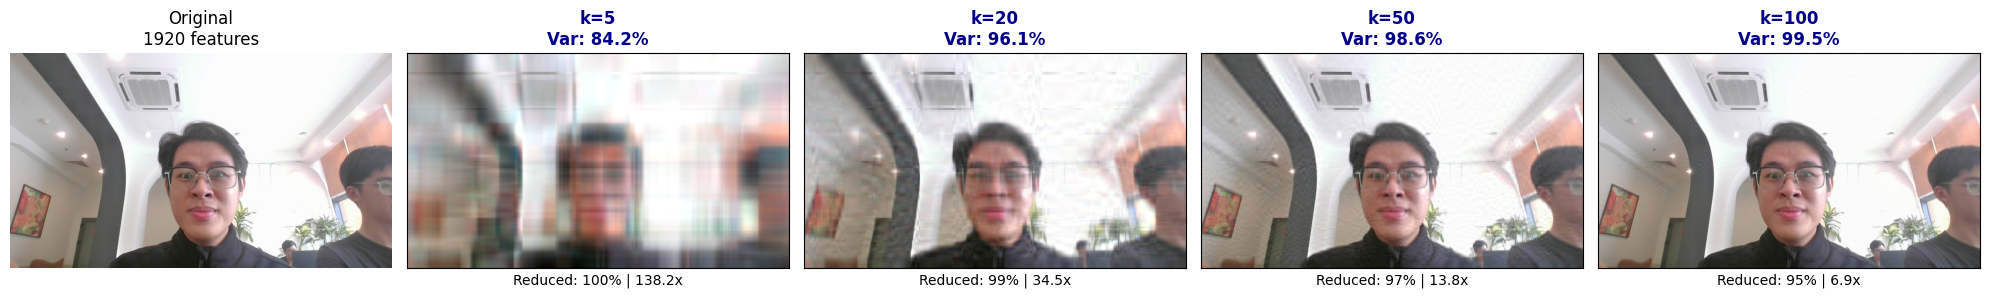


==================== TỔNG KẾT HIỆU NĂNG ====================


,Components (k),Variance (%),Reduction,Ratio
0,5,84.25%,-99.7%,138.2x
1,20,96.11%,-99.0%,34.5x
2,50,98.63%,-97.4%,13.8x
3,100,99.50%,-94.8%,6.9x


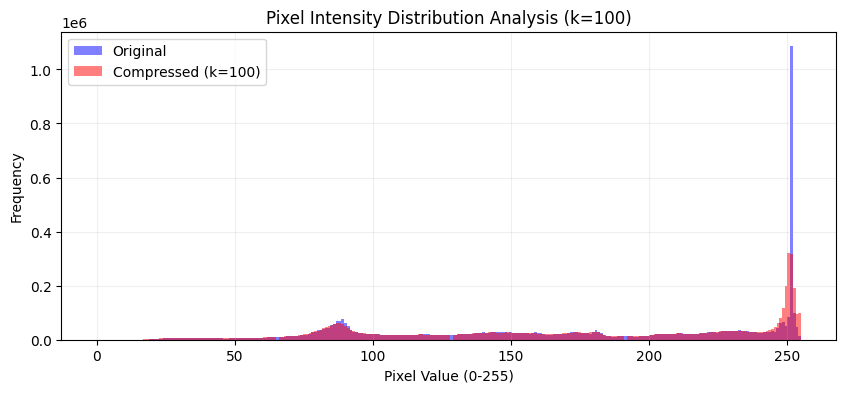

In [22]:
path = "./thuan.jpg"

# PCA thường hội tụ nhanh, nên k không cần quá lớn
# k ở đây đóng vai trò là số lượng Principal Components
my_k_pca = [5, 20, 50, 100] 

print(">>> Đang thực hiện nén ảnh bằng PCA (sklearn)...")
visualize_pca_comparison(path, my_k_pca)
